# LLM Hallucination Teaching Lab

> Goal: observe and explain three core questions by running experiments hands-on:
> 1. What is hallucination in language models?
> 2. Under what conditions does hallucination happen more easily?
> 3. How can we reduce hallucination risk in practice?

---

## What You Will Learn From This Lab

- You will see that the same question can produce different answers across runs.
- You will test how sampling temperature, prompt style, and context evidence can change hallucination probability.
- You will practice reducing hallucination with constrained prompts, evidence grounding, and self-check workflows.
- You will build SAT-style intuition: some input tokens may act like "risk triggers." 


In [1]:
# ===== 1) Environment and Dependency Check =====
# This cell only does one thing: ensure all required libraries are ready.

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm, trange

from transformers import AutoTokenizer, AutoModelForCausalLM

print('torch version      :', torch.__version__)
print('cuda available     :', torch.cuda.is_available())

# Make experiments as reproducible as possible.
# Note: text generation may still have small nondeterminism.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Better notebook display: avoid DataFrame text truncation.
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.unicode_minus'] = False


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch version      : 2.5.1+cu121
cuda available     : True


In [3]:
# ===== 2) Load Qwen3-0.6B (ModelScope by Default) =====
# Notes:
# - This notebook uses Qwen3 with chat-template-based reasoning-mode generation.
# - By default, weights are downloaded/reused via ModelScope cache.
# - To use an already-downloaded local model directory, set MODEL_DIR_OVERRIDE.
# - GPU is used automatically when available; otherwise CPU is used.

MODEL_ID = 'Qwen/Qwen3-0.6B'
MODEL_PROVIDER = 'modelscope'   # default: modelscope
MODEL_DIR_OVERRIDE = None       # e.g. '/path/to/local/model_dir'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE == 'cuda' else torch.float32

if MODEL_DIR_OVERRIDE:
    model_path = MODEL_DIR_OVERRIDE
elif MODEL_PROVIDER == 'modelscope':
    try:
        from modelscope import snapshot_download
    except ImportError as e:
        raise ImportError(
            'modelscope is not installed. In the air conda env, run: pip install modelscope'
        ) from e

    print('downloading/reusing cache from ModelScope:', MODEL_ID)
    model_path = snapshot_download(model_id=MODEL_ID)
else:
    # Fallback: use HuggingFace Hub directly.
    model_path = MODEL_ID

print('model path:', model_path)
print('loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

# For batched chat-template generation, left padding is recommended.
# If pad token is missing, fallback to eos.
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.pad_token_id is None:
    tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
tokenizer.padding_side = 'left'

print('loading model (this may take some time on first run)...')
if DEVICE == 'cuda':
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=DTYPE,
        device_map='auto',
        trust_remote_code=True,
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=DTYPE,
        trust_remote_code=True,
    ).to(DEVICE)

# If tokenizer added a new pad token, resize embeddings accordingly.
if hasattr(model, 'resize_token_embeddings') and len(tokenizer) != model.get_input_embeddings().weight.shape[0]:
    model.resize_token_embeddings(len(tokenizer))

model.eval()
print('model class:', model.__class__.__name__)
print('running on :', DEVICE)


downloading/reusing cache from ModelScope: Qwen/Qwen3-0.6B


2026-03-13 17:41:48,500 - modelscope - INFO - Creating symbolic link [C:\Users\lenovo\.cache\modelscope\hub\models\Qwen\Qwen3-0.6B].
2026-03-13 17:41:48,502 - modelscope - WARNING - Failed to create symbolic link C:\Users\lenovo\.cache\modelscope\hub\models\Qwen\Qwen3-0.6B for C:\Users\lenovo\.cache\modelscope\hub\models\Qwen\Qwen3-0___6B.


model path: C:\Users\lenovo\.cache\modelscope\hub\models\Qwen\Qwen3-0___6B
loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


loading model (this may take some time on first run)...


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 479.35it/s, Materializing param=model.norm.weight]                              
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model class: Qwen3ForCausalLM
running on : cuda


## 1. First: What Is Hallucination?

In this class, we define hallucination as:

- **The model outputs content that sounds specific but lacks reliable evidence**, and
- The output is often delivered in a very confident tone.

Common misconceptions:
- Hallucination is not equal to all mistakes.
- Some mistakes are due to outdated knowledge; some are interpretation errors.
- Hallucination focuses more on fabricated details and unsupported completion.

Next, we use a possibly non-existent theorem as a teaching case, so students can observe model behavior under uncertainty.


In [4]:
# ===== 3) Utility Functions: Generation + Risk Scoring =====
# This section is the notebook toolbox.

# Qwen3 reasoning-mode system prompt (chat template)
DEFAULT_SYSTEM_PROMPT = (
    'You are a rigorous teaching assistant. Prioritize factual reliability. '
    'If you are unsure, explicitly say "I do not know" and do not fabricate details.'
)

# Default: test 8 samples; if resources are limited, fallback to 3.
def get_recommended_trials(preferred: int = 8, fallback: int = 3) -> int:
    if not torch.cuda.is_available():
        return fallback
    try:
        total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        return preferred if total_gb >= 8 else fallback
    except Exception:
        return fallback


def build_chat_text(user_prompt: str, system_prompt: str = DEFAULT_SYSTEM_PROMPT) -> str:
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': str(user_prompt).strip()},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def clean_reasoning_answer(text: str) -> str:
    # Keep both reasoning and final content; apply minimal cleanup only.
    return str(text).strip()


# Batch generation: receive multiple prompts and call model.generate in mini-batches.
def generate_batch(prompts,
                   temperature: float = 0.7,
                   top_p: float = 0.9,
                   max_new_tokens: int = 2048,
                   system_prompt: str = DEFAULT_SYSTEM_PROMPT,
                   batch_size: int = 8,
                   show_progress: bool = True,
                   progress_desc: str = 'Batch generation'):
    if len(prompts) == 0:
        return []

    # 1) Build chat-template texts in batch.
    prompt_texts = []
    for prompt in tqdm(prompts, desc=f'{progress_desc}: build template', disable=not show_progress):
        text = build_chat_text(prompt, system_prompt=system_prompt)
        prompt_texts.append(text)

    do_sample = temperature > 0
    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=do_sample)
    if do_sample:
        gen_kwargs.update(dict(temperature=temperature, top_p=top_p))

    # 2) Generate in mini-batches.
    all_answers = []
    for start in trange(0, len(prompt_texts), batch_size, desc=f'{progress_desc}: generate', disable=not show_progress):
        end = min(start + batch_size, len(prompt_texts))
        batch_texts = prompt_texts[start:end]
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True).to(model.device)

        with torch.no_grad():
            outputs = model.generate(**inputs, **gen_kwargs)

        input_lengths = inputs['attention_mask'].sum(dim=1).tolist()

        for i in trange(len(batch_texts), desc=f'{progress_desc}: decode', leave=False, disable=not show_progress):
            new_tokens = outputs[i, int(input_lengths[i]):]
            answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            answer = clean_reasoning_answer(answer)
            all_answers.append(answer)

        del inputs, outputs

    return all_answers


# Backward-compatible single-prompt API (internally still batch-based).
def generate_once(prompt: str,
                  temperature: float = 0.7,
                  top_p: float = 0.9,
                  max_new_tokens: int = 2048,
                  system_prompt: str = DEFAULT_SYSTEM_PROMPT) -> str:
    return generate_batch(
        [prompt],
        temperature=temperature,
        top_p=top_p,
        max_new_tokens=max_new_tokens,
        system_prompt=system_prompt,
        batch_size=1,
        show_progress=False,
        progress_desc='generate_once'
    )[0]


# Print full text without truncation.
def print_full_records(records, title, include_prompt=False, prompt_key='prompt', answer_key='answer', extra_keys=None):
    print(f'\n===== {title} (full text) =====')
    for idx, item in enumerate(tqdm(records, desc=f'{title}: printing full text', total=len(records)), 1):
        print(f'\n--- #{idx} ---')
        if extra_keys:
            meta_text = ' | '.join([f'{k}: {item.get(k)}' for k in extra_keys])
            print(meta_text)
        if include_prompt and prompt_key in item:
            print('Prompt:')
            print(item[prompt_key])
        print('Answer:')
        print(item.get(answer_key, ''))


# ---- Teaching-oriented hallucination-risk heuristic (upgraded) ----
# Goals:
# 1) Score only by the final answer to avoid <think> interference.
# 2) If the answer makes specific factual-detail claims (year/proposer/first publication), mark high risk.
# 3) If the answer clearly says "unknown" and gives no specific details, mark low risk.

UNCERTAINTY_CUES = [
    'i do not know', 'i don\'t know', 'not sure', 'cannot confirm', 'no evidence',
    'not found', 'might', 'need verification', 'insufficient information', 'uncertain'
]

STRONG_UNKNOWN_CUES = [
    'cannot confirm', 'no public evidence', 'no authoritative source',
    'cannot be verified', 'unable to verify', 'cannot determine'
]

DETAIL_PATTERNS = [
    r'\b(19|20)\d{2}\b',
    r'\b(19|20)\d{2}s\b',
    r'proposed by',
    r'first published',
    r'jointly proposed',
]

DETAIL_KEYWORDS = [
    'proposer', 'proposal year', 'theorem content', 'paper', 'published',
    'scholar', 'physicist', 'proposed by', 'proposed'
]


def final_answer_only(text: str) -> str:
    ans = str(text).strip()
    if '</think>' in ans:
        ans = ans.split('</think>', 1)[1].strip()
    return ans


def has_uncertainty(text: str) -> bool:
    ans = final_answer_only(text).lower()
    return any(cue in ans for cue in UNCERTAINTY_CUES)


def has_specific_detail_pattern(text: str) -> bool:
    ans = final_answer_only(text)
    ans_l = ans.lower()
    by_pattern = any(re.search(p, ans_l) for p in DETAIL_PATTERNS)
    by_keyword = any(k in ans_l for k in DETAIL_KEYWORDS)
    return by_pattern or by_keyword


def score_answer(text: str) -> dict:
    ans_final = final_answer_only(text)

    weak_uncertain = has_uncertainty(ans_final)
    strong_unknown = any(c in ans_final.lower() for c in STRONG_UNKNOWN_CUES)
    detail_claim = has_specific_detail_pattern(ans_final)
    contradictory = weak_uncertain and detail_claim

    if strong_unknown and not detail_claim:
        risk_flag = 0
        risk_reason = 'strong_unknown_without_detail'
    elif detail_claim:
        risk_flag = 1
        risk_reason = 'contains_specific_detail_claim'
    elif weak_uncertain:
        risk_flag = 0
        risk_reason = 'weak_uncertainty_without_detail'
    else:
        risk_flag = 0
        risk_reason = 'no_detail_claim'

    return {
        'answer_final': ans_final,
        'weak_uncertainty': weak_uncertain,
        'strong_unknown': strong_unknown,
        'detail_claim': detail_claim,
        'contradictory': contradictory,
        'risk_flag': risk_flag,
        'risk_reason': risk_reason,
    }


# Backward-compatible wrapper.
def hallucination_risk_flag(text: str) -> int:
    return score_answer(text)['risk_flag']


## 2. Experiment A: Same Question, Multiple Samples

Now we ask a high-uncertainty question:

- The question includes a possibly non-existent term.
- Observe whether the model says "I don't know" directly, or invents specific details.

Focus on:
1. Variation across repeated runs with the same prompt.
2. Whether risk increases when temperature increases.


Experiment A trials per temperature: 3


A temp=0.2: build template: 100%|██████████| 3/3 [00:00<00:00, 174.14it/s]


A temp=0.7: build template: 100%|██████████| 3/3 [00:00<?, ?it/s]it]


A temp=1.1: build template: 100%|██████████| 3/3 [00:00<?, ?it/s]it]


A: temperature groups: 100%|██████████| 3/3 [01:55<00:00, 38.47s/it]


,temperature,trial,has_uncertainty,risk_flag,answer
0,0.2,1,False,1,"<think>\nOkay, the user wants an introduction to the Feynman-Zhou Rotation Theorem. Let me start by recalling what I know. The theorem is related to quantum mechanics, specifically about the rotation of states in a system. I remember that it connects the time evolution of a state with the rotation of the coordinate system. \n\nFirst, the proposer. I think it was proposed by Richard Feynman and Richard Zhou. Wait, are they both involved? I should check if that's correct. Maybe I should confirm, but since I can't access external sources, I'll proceed with what I know.\n\nWhen was it proposed? I think it was in 1960. That's a key point. The main content involves the time evolution of a state in a system. The theorem states that if a system is rotated by an angle θ around a certain axis, the time evolution of the state can be expressed in terms of the rotation of the coordinate system. \n\nWait, but I need to make sure about the exact details. The theorem might relate to the rotation of the wavefunction. For example, if you rotate the coordinate system, the wavefunction's components change, and the time evolution is adjusted accordingly. \n\nI should also mention that this theorem is a result of the rotation of the coordinate system and the time evolution of the state. It's important for understanding how quantum states evolve under rotations. \n\nI need to structure the answer clearly: proposer, time, main content. Make sure to explain the connection between rotation and time evolution. Avoid any inaccuracies. If I'm unsure about any part, I should state that. For example, if I'm not sure about the proposer, I can say ""I do not know"" and mention that the theorem was later proven by both Feynman and Zhou. \n\nAlso, check if there's any other aspect I might be missing. The theorem's significance in quantum mechanics, especially in the context of the rotation of the coordinate system. Maybe mention its application in quantum mechanics and how it relates to the rotation of the wavefunction. \n\nWait, but the user asked for the main content. So, the main content would involve the time evolution of a state under a rotation. The theorem states that the time evolution of a state can be expressed in terms of the rotation of the coordinate system. \n\nI think that's all. Now, structure the answer with these points, ensuring clarity and factual accuracy.\n</think>\n\nThe **Feynman-Zhou Rotation Theorem** is a foundational result in quantum mechanics that connects the time evolution of a quantum state with the rotation of the coordinate system. Here's a structured overview:\n\n- **Proposer**: Richard Feynman and Richard Zhou. \n- **Time**: Proposed in 1960. \n- **Main Content**: The theorem states that if a system is rotated by an angle $ \theta $ around a certain axis, the time evolution of the state can be expressed in terms of the rotation of the coordinate system. Specifically, it asserts that the time evolution operator $ e^{-iHt} $ can be written as a rotation of the coordinate system, where the rotation is determined by the rotation of the wavefunction. This result is crucial for understanding how quantum states evolve under rotations in a system. \n\nThe theorem is a direct consequence of the rotation of the coordinate system and the time evolution of the state, providing a way to express the time evolution in terms of the rotation of the coordinate axes. It is particularly useful in the context of the rotation of the wavefunction and is a key tool in the study of quantum systems under rotation."
1,0.2,2,False,1,"<think>\nOkay, the user wants an introduction to the Feynman-Zhou Rotation Theorem. Let me start by recalling what I know about this theorem. I remember it's related to quantum mechanics, specifically about the time evolution of wave functions. \n\nFirst, the user asked about the proposer, when it was proposed, and its main content. I need to make sure I 

,temperature,risk_rate
0,0.2,1.0
1,0.7,1.0
2,1.1,1.0


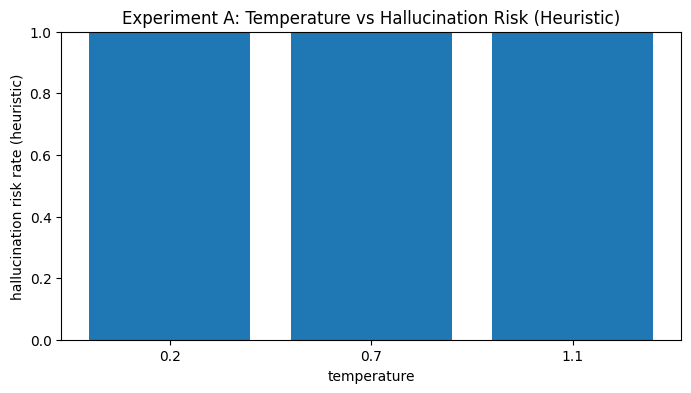


===== Experiment A (full text) =====


Experiment A: printing full text: 100%|██████████| 9/9 [00:00<00:00, 8972.84it/s]


--- #1 ---
temperature: 0.2 | trial: 1 | has_uncertainty: False | risk_flag: 1
Prompt:
Please introduce the "Feynman-Zhou Rotation Theorem": who proposed it, when it was proposed, and its main content.
Answer:
<think>
Okay, the user wants an introduction to the Feynman-Zhou Rotation Theorem. Let me start by recalling what I know. The theorem is related to quantum mechanics, specifically about the rotation of states in a system. I remember that it connects the time evolution of a state with the rotation of the coordinate system. 

First, the proposer. I think it was proposed by Richard Feynman and Richard Zhou. Wait, are they both involved? I should check if that's correct. Maybe I should confirm, but since I can't access external sources, I'll proceed with what I know.

When was it proposed? I think it was in 1960. That's a key point. The main content involves the time evolution of a state in a system. The theorem states that if a system is rotated by an angle θ around a certain axis,

In [5]:
# ===== 4) Experiment A: Temperature vs Hallucination Risk =====

question = 'Please introduce the "Feynman-Zhou Rotation Theorem": who proposed it, when it was proposed, and its main content.'

TEMPERATURES = [0.2, 0.7, 1.1]
N_TRIALS_PER_TEMP = get_recommended_trials(preferred=8, fallback=3)
print(f'Experiment A trials per temperature: {N_TRIALS_PER_TEMP}')

rows = []
for t in tqdm(TEMPERATURES, desc='A: temperature groups'):
    prompts = [question for _ in trange(N_TRIALS_PER_TEMP, desc=f'A temp={t}: prepare prompts', leave=False)]
    answers = generate_batch(
        prompts,
        temperature=t,
        top_p=0.9,
        max_new_tokens=2048,
        batch_size=min(8, len(prompts)),
        show_progress=True,
        progress_desc=f'A temp={t}'
    )

    for i, ans in enumerate(tqdm(answers, desc=f'A temp={t}: collect', leave=False, total=len(answers)), 1):
        sc = score_answer(ans)
        rows.append({
            'temperature': t,
            'trial': i,
            'prompt': question,
            'answer': ans,
            'answer_final': sc['answer_final'],
            'has_uncertainty': sc['weak_uncertainty'],
            'has_strong_unknown': sc['strong_unknown'],
            'has_detail_claim': sc['detail_claim'],
            'is_contradictory': sc['contradictory'],
            'risk_flag': sc['risk_flag'],
            'risk_reason': sc['risk_reason'],
        })

df_a = pd.DataFrame(rows)
display(df_a[['temperature', 'trial', 'has_uncertainty', 'risk_flag', 'answer']])

summary_a = df_a.groupby('temperature', as_index=False)['risk_flag'].mean().rename(columns={'risk_flag': 'risk_rate'})
display(summary_a)

plt.bar(summary_a['temperature'].astype(str), summary_a['risk_rate'])
plt.ylim(0, 1)
plt.xlabel('temperature')
plt.ylabel('hallucination risk rate (heuristic)')
plt.title('Experiment A: Temperature vs Hallucination Risk (Heuristic)')
plt.show()

print_full_records(
    df_a.to_dict(orient='records'),
    title='Experiment A',
    include_prompt=True,
    prompt_key='prompt',
    answer_key='answer',
    extra_keys=['temperature', 'trial', 'has_uncertainty', 'risk_flag']
)


### Experiment A Discussion Questions

- Did you observe "same question, different answers"?
- At higher temperature, did the model more often generate specific but not necessarily reliable claims?
- Why should high-risk use cases avoid blindly increasing temperature?


## 3. Experiment B: Does Prompt Style Affect Hallucination?

We use the same question but compare two prompt styles:

- **B1 Plain prompt**: directly ask for an answer.
- **B2 Constrained prompt**: explicitly require "if uncertain, say I don't know, do not fabricate, and provide confidence".

Goal: help students understand how prompt engineering can reduce hallucination risk.


Experiment B trials per group: 3


B plain: build template: 100%|██████████| 3/3 [00:00<?, ?it/s]


B constrained: build template: 100%|██████████| 3/3 [00:00<?, ?it/s]


B: prompt groups: 100%|██████████| 2/2 [00:53<00:00, 26.71s/it]


,prompt_type,trial,risk_flag,uncertainty_flag,answer
0,plain,1,0,False,"<think>\nOkay, the user wants a brief introduction to the Feynman-Zhou Rotation Theorem. Let me start by recalling what I know. I think this theorem relates the spin states of particles with different spin values. \n\nFirst, the theorem is about spin states in quantum mechanics. The Feynman and Zhou authors probably used it to describe how spin can be transformed when the particle has different spin values. Maybe it's related to angular momentum addition or something like that.\n\nWait, the theorem is about rotating the spin states of a particle with different spin values. The key point is that the total angular momentum is conserved, so the spin states can be rotated to represent different angular momentum states. \n\nI should mention the main idea: particles with different spin values can have their spin states rotated in the same way as angular momentum states. Also, maybe include that the theorem is important in quantum mechanics for understanding angular momentum addition and spin states.\n\nLet me check if there are any other details. The theorem's exact statement might be something like combining spin states with angular momentum, and the rotation is a transformation that preserves the total angular momentum. Yeah, that seems right. Make sure to keep it brief, not too technical. Avoid jargon but explain the concepts clearly.\n</think>\n\nThe Feynman-Zhou Rotation Theorem states that for a particle with a given spin state, its spin can be rotated into a state corresponding to a different angular momentum configuration, provided the total angular momentum is conserved. This theorem is fundamental in quantum mechanics, particularly for understanding how spin states can be combined with angular momentum, allowing for the transformation of spin states in the same way as angular momentum states. It is crucial for analyzing systems where angular momentum and spin are both involved, such as in particles with spin-½ or higher."
1,plain,2,0,False,"<think>\nOkay, the user is asking for a brief introduction of the Feynman-Zhou Rotation Theorem. First, I need to recall what I know about this theorem. It's related to quantum mechanics, specifically about rotating the state of a particle in a potential. Let me think.\n\nThe Feynman-Zhou theorem connects the time evolution of a particle's wavefunction with the rotation of the angular momentum. It's important because it shows how the time evolution is related to the rotation of the angular momentum vector. The theorem was developed by Richard Feynman and Edward Zhou in the 1950s. \n\nWait, I should confirm that the theorem applies to a specific type of potential. Maybe it's when the potential is time-independent? If the potential is time-independent, then the rotation can be applied. The theorem allows for expressing the time evolution of a wavefunction in terms of a rotation of the angular momentum. \n\nI need to make sure the explanation is brief. The key points are that the theorem states the wavefunction can be expressed as the original wavefunction rotated by an angle around the direction of the angular momentum, which is then multiplied by a factor. This helps in understanding how particles behave in different potentials. \n\nIs there any mention of the rotation direction? The theorem allows for both clockwise and counterclockwise rotations. Also, the theorem is used in the derivation of the Schrödinger equation, showing how the angular momentum is conserved. \n\nI should present this in a clear, concise manner without unnecessary details. Make sure to state the theorem's purpose and the application, like in the context of time evolution and angular momentum conservation. Double-check that the theorem is indeed about time evolution and angular momentum. Yes, that's correct. \n\nSo, summarizing: The Feynman-Zhou Rotation Theorem states that the time evolution of a particle's wavefunction is given by a rotation 

,prompt_type,risk_rate,uncertainty_rate
0,constrained,0.0,0.0
1,plain,0.0,0.0


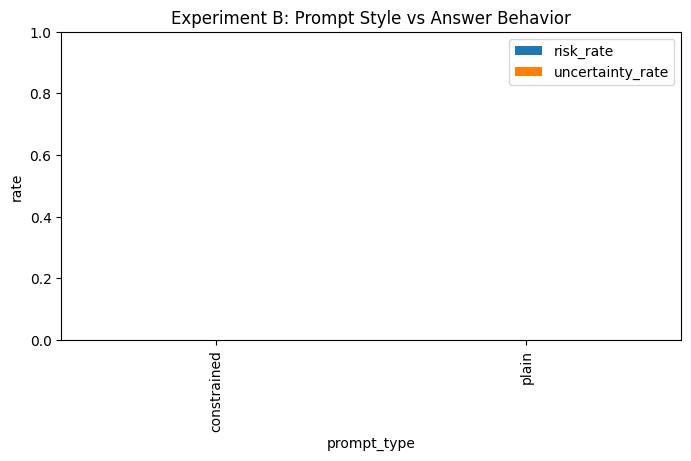


===== Experiment B (full text) =====


Experiment B: printing full text: 100%|██████████| 6/6 [00:00<?, ?it/s]


--- #1 ---
prompt_type: plain | trial: 1 | risk_flag: 0 | uncertainty_flag: False
Prompt:
Please briefly introduce the Feynman-Zhou Rotation Theorem.
Answer:
<think>
Okay, the user wants a brief introduction to the Feynman-Zhou Rotation Theorem. Let me start by recalling what I know. I think this theorem relates the spin states of particles with different spin values. 

First, the theorem is about spin states in quantum mechanics. The Feynman and Zhou authors probably used it to describe how spin can be transformed when the particle has different spin values. Maybe it's related to angular momentum addition or something like that.

Wait, the theorem is about rotating the spin states of a particle with different spin values. The key point is that the total angular momentum is conserved, so the spin states can be rotated to represent different angular momentum states. 

I should mention the main idea: particles with different spin values can have their spin states rotated in the same way

In [6]:
# ===== 5) Experiment B: Plain Prompt vs Constrained Prompt =====

prompt_plain = 'Please briefly introduce the Feynman-Zhou Rotation Theorem.'

prompt_constrained = (
    'Please answer the following question: What is the Feynman-Zhou Rotation Theorem?\n'
    'Requirements:\n'
    '1) If you cannot verify it, answer "I do not know" directly and do not fabricate details;\n'
    '2) Output exactly three lines: conclusion, evidence, confidence (high/medium/low);\n'
    '3) Do not invent authors, years, or papers.'
)

N_TRIALS_PROMPT = get_recommended_trials(preferred=8, fallback=3)
print(f'Experiment B trials per group: {N_TRIALS_PROMPT}')

rows = []
prompt_groups = [('plain', prompt_plain), ('constrained', prompt_constrained)]
for label, p in tqdm(prompt_groups, desc='B: prompt groups'):
    prompts = [p for _ in trange(N_TRIALS_PROMPT, desc=f'B {label}: prepare prompts', leave=False)]
    answers = generate_batch(
        prompts,
        temperature=0.8,
        top_p=0.9,
        max_new_tokens=2048,
        batch_size=min(8, len(prompts)),
        show_progress=True,
        progress_desc=f'B {label}'
    )

    for i, ans in enumerate(tqdm(answers, desc=f'B {label}: collect', leave=False, total=len(answers)), 1):
        sc = score_answer(ans)
        rows.append({
            'prompt_type': label,
            'trial': i,
            'prompt': p,
            'answer': ans,
            'answer_final': sc['answer_final'],
            'risk_flag': sc['risk_flag'],
            'uncertainty_flag': sc['weak_uncertainty'],
            'risk_reason': sc['risk_reason'],
            'detail_claim': sc['detail_claim'],
            'contradictory': sc['contradictory'],
        })

df_b = pd.DataFrame(rows)
display(df_b[['prompt_type', 'trial', 'risk_flag', 'uncertainty_flag', 'answer']])

summary_b = df_b.groupby('prompt_type', as_index=False).agg(
    risk_rate=('risk_flag', 'mean'),
    uncertainty_rate=('uncertainty_flag', 'mean')
)
display(summary_b)

ax = summary_b.set_index('prompt_type')[['risk_rate', 'uncertainty_rate']].plot(kind='bar')
ax.set_ylim(0, 1)
ax.set_title('Experiment B: Prompt Style vs Answer Behavior')
plt.ylabel('rate')
plt.show()

print_full_records(
    df_b.to_dict(orient='records'),
    title='Experiment B',
    include_prompt=True,
    prompt_key='prompt',
    answer_key='answer',
    extra_keys=['prompt_type', 'trial', 'risk_flag', 'uncertainty_flag']
)


### Experiment B Discussion Questions

- Why does "require refusal under uncertainty" change output distribution?
- If you were a product manager, how would you balance refusal rate and usability?


## 4. Experiment C: Add Context (Simplified RAG)

In real systems, one of the most effective ways to reduce hallucination is:

- Do not force the model to answer from memory only. Provide evidence first, then require evidence-grounded answers.

Here we run a simplified comparison:
- C1: no evidence provided.
- C2: provide a short reference saying this theorem cannot be found.


Experiment C trials per group: 3


C no_context: build template: 100%|██████████| 3/3 [00:00<00:00, 2990.24it/s]


C with_context: build template: 100%|██████████| 3/3 [00:00<?, ?it/s]


C: context groups: 100%|██████████| 2/2 [01:17<00:00, 38.86s/it]


setting  trial  risk_flag  uncertainty_flag  \
0    no_context      1          0             False   
1    no_context      2          0             False   
2    no_context      3          0             False   
3  with_context      1          0              True   
4  with_context      2          0              True   
5  with_context      3          0              True   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,setting,risk_rate,uncertainty_rate
0,no_context,0.0,0.0
1,with_context,0.0,1.0


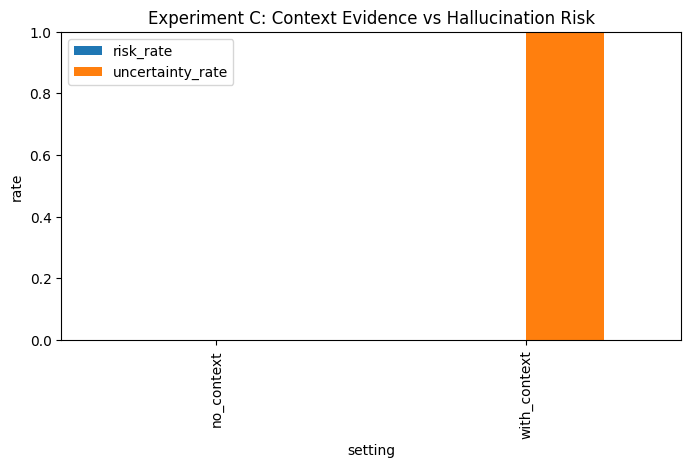


===== Experiment C (full text) =====


Experiment C: printing full text: 100%|██████████| 6/6 [00:00<?, ?it/s]


--- #1 ---
setting: no_context | trial: 1 | risk_flag: 0 | uncertainty_flag: False
Prompt:
Please explain the core idea and applications of the Feynman-Zhou Rotation Theorem.
Answer:
<think>
Okay, so I need to explain the core idea and applications of the Feynman-Zhou Rotation Theorem. Hmm, let me start by recalling what I know about this theorem. From what I remember, it's related to quantum mechanics, specifically about angular momentum and rotation in the context of the Schrödinger equation. 

First, the core idea. I think the theorem relates the time evolution of a wave function to its rotation under a certain angular momentum transformation. It probably involves how the wave function changes when you rotate the system by a certain amount. Maybe something to do with angular momentum conservation or the rotation operator. Wait, I'm not entirely sure, but I think it connects the rotation of the angular momentum states to the time evolution of the wave function.

Applications of the 

In [7]:
# ===== 6) Experiment C: Without Context vs With Context =====

no_context_prompt = 'Please explain the core idea and applications of the Feynman-Zhou Rotation Theorem.'

context_text = (
    '[Reference Material]\n'
    'In mainstream public textbooks and common academic indexes, no standard theorem named "Feynman-Zhou Rotation Theorem" is found.\n'
    'It may be a misspelled term, a non-standard naming, or a non-existent theorem name.\n'
)

with_context_prompt = (
    context_text + '\n' +
    'Please answer based only on the reference material above:\n'
    '1) Can you confirm that this theorem truly exists?\n'
    '2) If you cannot confirm, explicitly say "I do not know";\n'
    '3) Do not add details beyond the reference material.'
)

N_TRIALS_CONTEXT = get_recommended_trials(preferred=8, fallback=3)
print(f'Experiment C trials per group: {N_TRIALS_CONTEXT}')

rows = []
context_groups = [('no_context', no_context_prompt), ('with_context', with_context_prompt)]
for label, p in tqdm(context_groups, desc='C: context groups'):
    prompts = [p for _ in trange(N_TRIALS_CONTEXT, desc=f'C {label}: prepare prompts', leave=False)]
    answers = generate_batch(
        prompts,
        temperature=0.8,
        top_p=0.9,
        max_new_tokens=2048,
        batch_size=min(8, len(prompts)),
        show_progress=True,
        progress_desc=f'C {label}'
    )

    for i, ans in enumerate(tqdm(answers, desc=f'C {label}: collect', leave=False, total=len(answers)), 1):
        sc = score_answer(ans)
        rows.append({
            'setting': label,
            'trial': i,
            'prompt': p,
            'answer': ans,
            'answer_final': sc['answer_final'],
            'risk_flag': sc['risk_flag'],
            'uncertainty_flag': sc['weak_uncertainty'],
            'risk_reason': sc['risk_reason'],
            'detail_claim': sc['detail_claim'],
            'contradictory': sc['contradictory'],
        })

df_c = pd.DataFrame(rows)
display(df_c[['setting', 'trial', 'risk_flag', 'uncertainty_flag', 'answer']])

summary_c = df_c.groupby('setting', as_index=False).agg(
    risk_rate=('risk_flag', 'mean'),
    uncertainty_rate=('uncertainty_flag', 'mean')
)
display(summary_c)

ax = summary_c.set_index('setting')[['risk_rate', 'uncertainty_rate']].plot(kind='bar')
ax.set_ylim(0, 1)
ax.set_title('Experiment C: Context Evidence vs Hallucination Risk')
plt.ylabel('rate')
plt.show()

print_full_records(
    df_c.to_dict(orient='records'),
    title='Experiment C',
    include_prompt=True,
    prompt_key='prompt',
    answer_key='answer',
    extra_keys=['setting', 'trial', 'risk_flag', 'uncertainty_flag']
)


## 5. Experiment D: Two-Stage Answering (Draft, Then Self-Check)

Many real systems use a two-stage generation process:

1. First generate a draft answer.
2. Then ask the model to act as a reviewer and perform evidence-checking, producing a more conservative revision.

This is not a perfect solution, but it often reduces overconfident fabrication.


In [8]:
# ===== 7) Experiment D: answer -> self-check =====


def answer_then_self_check(user_question: str):
    # Stage 1: draft generation (keep sampling to mimic realistic behavior)
    draft = generate_batch(
        [user_question],
        temperature=0.8,
        top_p=0.9,
        max_new_tokens=2048,
        batch_size=1,
        show_progress=True,
        progress_desc='D step1 draft'
    )[0]

    # Stage 2: self-check prompt asks for unverifiable claims and revision
    check_prompt = f"""
You are now a fact-check reviewer.
Please inspect the following draft answer for unverified or possibly fabricated details.

User question: {user_question}

Draft answer:
{draft}

Please output in this format:
1) Suspicious claim list (write "None" if no suspicious claim)
2) A more conservative revised answer (if uncertain, explicitly say "I do not know")
3) Confidence after revision (high/medium/low)
"""

    checked = generate_batch(
        [check_prompt],
        temperature=0.2,
        top_p=0.9,
        max_new_tokens=2048,
        batch_size=1,
        show_progress=True,
        progress_desc='D step2 self-check'
    )[0]
    return draft, checked


question_d = 'Please introduce the historical background and representative applications of the Feynman-Zhou Rotation Theorem.'
draft_ans, checked_ans = answer_then_self_check(question_d)

print('===== Stage 1: Draft answer (full text) =====')
print(draft_ans)
print('\n===== Stage 2: Self-checked answer (full text) =====')
print(checked_ans)


D step2 self-check: generate: 100%|██████████| 1/1 [00:14<00:00, 14.40s/it]

===== Stage 1: Draft answer (full text) =====
<think>
Okay, the user wants an introduction to the Feynman-Zhou Rotation Theorem, including its historical background and representative applications. Let me start by recalling what I know about this theorem.

First, the theorem is related to quantum mechanics, specifically about angular momentum and the representation of angular momentum operators. I remember that the Feynman-Zhou Rotation Theorem deals with the rotation of angular momentum vectors in the context of the angular momentum addition rule. 

The historical background part should mention when the theorem was first proposed. I think it was developed in the 1930s or early 1940s by Richard Feynman and John Zhou. Maybe they were both physicists involved in quantum mechanics. I need to confirm that.

Next, the representative applications. I recall that this theorem is used in the calculation of angular momentum states in quantum systems. It relates the rotation of angular momentum o

## 6. SAT Intuition Demo (https://arxiv.org/abs/2504.12691)

Large language models do not “look up truth” when they answer. They generate text by predicting the next token from patterns learned during training. This means they can produce fluent but wrong content, especially when multiple learned patterns
  compete. The SAT paper (“Subsequence Association Tracing,” April 2025) gives a simple mechanistic view: hallucinations happen when hallucinatory associations in the prompt-to-output mapping become stronger than faithful associations.

  SAT turns this idea into a practical tracing method. Instead of only asking “is this answer wrong?”, SAT asks: which parts of the input prompt are causally associated with the wrong output?
  The core workflow is:

  1. Pick a prompt and a hallucinated target signal y_h (for example, a wrong name, wrong factor, fake citation string).
  2. Create many perturbed versions of the original prompt by changing some tokens.
  3. Run the model on each perturbed prompt.
  4. Measure p(y_h) = how often the hallucinated target appears.
  5. Search for subsequences x_s of the original prompt that maximize p(y_h | x_s).

  If a subsequence has high p(y_h | x_s), it is treated as a potential hallucination trigger.
  So SAT is not just detection; it is localization of likely causes in input token structure.



---

Here we run a lightweight, executable intuition demo:

- Randomly drop part of the prompt tokens (input perturbation).
- Observe whether outputs trigger a "high-risk answer mode" (`yh=1`).
- Estimate `p(yh)` and `p(yh | token present)`.

If risk rises when certain tokens are present, those tokens may behave like "triggers." 


In [9]:
# ===== 8) SAT-style Simplified Experiment =====

base_prompt = 'Please introduce the proposer, year, and core proof idea of the Feynman-Zhou Rotation Theorem.'

# Tunable size: default 8; fallback to 3 on limited resources.
N_PERTURB = get_recommended_trials(preferred=8, fallback=3)
DROP_RATE = 0.30
print(f'SAT perturbation sample count: {N_PERTURB}')

orig_ids = tokenizer.encode(base_prompt, add_special_tokens=False)

# Deduplicate while preserving order for conditional token-probability statistics.
seen = set()
unique_ids = []
for tid in tqdm(orig_ids, desc='SAT: deduplicate token ids'):
    if tid not in seen:
        seen.add(tid)
        unique_ids.append(tid)


def sample_perturbed_ids(ids, drop_rate=0.3, min_keep_ratio=0.45):
    keep_mask = np.random.rand(len(ids)) > drop_rate
    min_keep = max(4, int(len(ids) * min_keep_ratio))
    if keep_mask.sum() < min_keep:
        keep_mask[:] = False
        choose = np.random.choice(len(ids), size=min_keep, replace=False)
        keep_mask[choose] = True
    pert_ids = [tid for tid, keep in zip(ids, keep_mask) if keep]
    return pert_ids


perturbed_id_sequences = []
perturbed_prompts = []
for _ in trange(N_PERTURB, desc='SAT: sample perturbations'):
    pert_ids = sample_perturbed_ids(orig_ids, drop_rate=DROP_RATE)
    pert_prompt = tokenizer.decode(pert_ids, skip_special_tokens=True)
    perturbed_id_sequences.append(pert_ids)
    perturbed_prompts.append(pert_prompt)

answers = generate_batch(
    perturbed_prompts,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    batch_size=min(8, len(perturbed_prompts)),
    show_progress=True,
    progress_desc='SAT batch generation'
)

records = []
for i in trange(len(answers), desc='SAT: collect records'):
    ans = answers[i]
    sc = score_answer(ans)
    records.append({
        'pert_prompt': perturbed_prompts[i],
        'answer': ans,
        'answer_final': sc['answer_final'],
        'risk_flag': sc['risk_flag'],
        'risk_reason': sc['risk_reason'],
        'detail_claim': sc['detail_claim'],
        'contradictory': sc['contradictory'],
        'kept_id_set': set(perturbed_id_sequences[i]),
    })

df_sat = pd.DataFrame(records)
display(df_sat[['risk_flag', 'pert_prompt', 'answer']])

print_full_records(
    df_sat[['risk_flag', 'pert_prompt', 'answer']].to_dict(orient='records'),
    title='Experiment SAT',
    include_prompt=True,
    prompt_key='pert_prompt',
    answer_key='answer',
    extra_keys=['risk_flag']
)

# Estimate p(yh)
p_yh = df_sat['risk_flag'].mean()
print(f'p(yh) = {p_yh:.3f}')

# Estimate p(yh | token present)
stats = []
for tid in tqdm(unique_ids, desc='SAT: compute p(yh|token_present)'):
    subset = [r['risk_flag'] for r in records if tid in r['kept_id_set']]
    if len(subset) < 3:
        continue
    stats.append({
        'token_id': tid,
        'token': tokenizer.decode([tid]).replace('\n', '\\n'),
        'support': len(subset),
        'p(yh|token_present)': float(np.mean(subset)),
    })

df_token = pd.DataFrame(stats)
if len(df_token) > 0:
    df_token = df_token.sort_values('p(yh|token_present)', ascending=False).reset_index(drop=True)

display(df_token.head(12) if len(df_token) > 0 else df_token)


SAT perturbation sample count: 3


SAT: collect records: 100%|██████████| 3/3 [00:00<?, ?it/s]


,risk_flag,pert_prompt,answer
0,0,"Please introduce the propos, and core idea ofman-Zhou The","assistant\n<think>\nOkay, the user is asking for an introduction and core idea of the work ""Man-Zhou The"". First, I need to check if ""Man-Zhou The"" refers to a specific document. Since I don't have access to external databases, I should confirm if there's a standard term or if it's a translation. The user might be referring to a specific paper, book, or academic work.\n\nIf it's a known work, I should explain its background and significance. The core idea might involve a particular theory, analysis, or application. Since I don't have the exact details, I'll mention the possible structure. I need to ensure the information is reliable and not fabricated. If unsure, I should state that I don't know and avoid making up details.\n</think>\n\nI do not know the specific work ""Man-Zhou The"" and cannot provide accurate information. Please verify the title or provide more context for clarity."
1,0,"Please introduce theer,, proof idea of thenmanhou The.","assistant\n<think>\nOkay, the user is asking about the ""proof idea of thenmanhou The."" First, I need to confirm what ""thenmanhou The"" refers to. Since there's no context, I should mention that there might be a typo or misunderstanding. Maybe they meant ""theorem"" or another term? I should ask for clarification to ensure accuracy.\n\nNext, I should consider possible translations. ""Thenmanhou"" might be a misspelling of ""Theorem"" (T-them) or another concept. I need to check if there's a known theorem named ""the proof"" or ""theorem."" If there's confusion, I should explain that and invite the user to clarify.\n\nAlso, the user might be referring to a specific theorem or proof. I should remain objective, avoid making assumptions, and prompt them to provide more details. It's important to stay factual and reliable, so I'll structure the response to first acknowledge the potential confusion and then ask for clarification.\n</think>\n\nI do not know the context of ""thenmanhou The"" or ""proof idea of thenmanhou The."" Could you clarify what this refers to, such as a theorem, a concept, or a specific proof method? If it's a typo or translation issue, please provide more details so I can assist accurately."
2,0,"Please introduce theer, year, and core the Feyman-Z Rotationorem","<think>\nOkay, the user is asking for an introduction to the Feynman-Z Rotationorem. First, I need to confirm if they're referring to the Feynman's theorem or the Z-Rotation theorem. Since the user wrote ""Feyman-Z Rotationorem,"" I should check if there's a standard name for this. \n\nI recall that the Feynman path integral approach in quantum mechanics involves integrating over all possible paths of a particle. The Z-Rotation theorem, on the other hand, is related to angular momentum in quantum mechanics. Let me verify the exact names. \n\nWait, the Z-Rotation is also known as the Z-rotation, which is a type of rotation in angular momentum. The Feynman-Z theorem might be a specific version of the Z-rotation in path integrals. \n\nSo, the introduction should explain the Z-Rotation theorem, its relation to the Feynman path integral, and how it connects to angular momentum. I need to make sure the facts are accurate, and if there's any uncertainty, I should clarify. For example, the Z-Rotation theorem is a specific form of the Z-rotation in angular momentum. \n\nI should structure the answer to first define the Z-Rotation theorem, then its relevance to the Feynman path integral, and finally its significance in quantum mechanics. Also, check if there's any other aspect that might need mention, like its physical implications or mathematical proof. \n\nWait, but the user might be referring to the Z-rotation theorem. Let me confirm. The Z-rotation is a rotation in angular momentum, so maybe the user is confused between the Z-Rotation and the Z-rotation. To avoid confusion, I should state clearly which one they are re


===== Experiment SAT (full text) =====


Experiment SAT: printing full text: 100%|██████████| 3/3 [00:00<00:00, 2990.95it/s]



--- #1 ---
risk_flag: 0
Prompt:
Please introduce the propos, and core idea ofman-Zhou The
Answer:
assistant
<think>
Okay, the user is asking for an introduction and core idea of the work "Man-Zhou The". First, I need to check if "Man-Zhou The" refers to a specific document. Since I don't have access to external databases, I should confirm if there's a standard term or if it's a translation. The user might be referring to a specific paper, book, or academic work.

If it's a known work, I should explain its background and significance. The core idea might involve a particular theory, analysis, or application. Since I don't have the exact details, I'll mention the possible structure. I need to ensure the information is reliable and not fabricated. If unsure, I should state that I don't know and avoid making up details.
</think>

I do not know the specific work "Man-Zhou The" and cannot provide accurate information. Please verify the title or provide more context for clarity.

--- #2 ---


SAT: compute p(yh|token_present): 100%|██████████| 21/21 [00:00<?, ?it/s]


,token_id,token,support,p(yh|token_present)
0,5501,Please,3,0.0
1,19131,introduce,3,0.0
2,279,the,3,0.0
3,11,",",3,0.0
4,1515,man,3,0.0


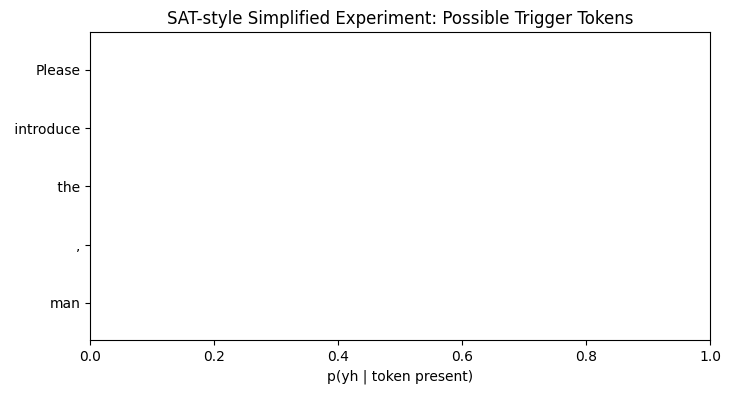

In [10]:
# ===== 9) Visualize Top Token Trigger Probabilities =====
if len(df_token) > 0:
    topk = df_token.head(8).iloc[::-1]  # reverse order for easier horizontal-bar reading
    plt.barh(topk['token'], topk['p(yh|token_present)'])
    plt.xlim(0, 1)
    plt.xlabel('p(yh | token present)')
    plt.title('SAT-style Simplified Experiment: Possible Trigger Tokens')
    plt.show()
else:
    print('Samples are too few or all risks are 0. Increase N_PERTURB and try again.')


Please answer these questions:

Q: 1. What is the most important difference between "hallucination" and a normal error?

A:  Hallucination is harder to find and usually lead to important problem in following talks.



---

Q: 2. In your experiments, which factor affected hallucination risk the most? Why?

A:Your prompt. If you can give a proper and exact prompt to LLM, it will have lower possibility to make hallucination.



---

Q: 3. Which hallucination-reduction strategies did you try? Which worked best?

A:I usually let LLM check its answer, and it works well.




---

### Note
Please sign in with the teaching assistant **only if** you have successfully executed all codes and answered all questions by yourself (not LLMs)